# PATH Simulation End-to-End Test
The purpose of this notebook is to create an end-to-end test for the PATH simulations, so that we can confirm proper functioning after the code refactoring. For this, I will complete the `default-KKO` simulation with DELS, defining the random seed beforehand. I will simulate only 1000 FRBs, for faster run-time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)

In [2]:
import pandas, time
import numpy as np
from chime_ffff_pz.path import priors
from path_simulations import run
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units
import scipy.stats as stats
#from zdm.chime import grids
#from zdm.loading import load_CHIME
from frb.galaxies import hosts as hosts_mod
from frb.frb_surveys import chime
from scipy.interpolate import interp1d
from frb.defs import frb_cosmo
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
from astropy.cosmology.realizations import Planck18 as cosmo
from astropy import units as u
from scipy.interpolate import LinearNDInterpolator, CloughTocher2DInterpolator, NearestNDInterpolator
import copy
import matplotlib
# JXP imports
from frb.dm import prob_dmz

/home/xavier/miniforge3/envs/astro/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/xavier/Projects/FRB/FRB/frb/halos/hmf.py:51: UserWarning: hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..
  warnings.warn("hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..")


In [3]:
import os
#os.environ['CHIME_SANDBOX'] = '/arc/projects/chime_frb/bandersen/path-simulations/simulation_results/SIMULATIONS_FINAL/'
os.environ['CHIME_SANDBOX'] = '/home/xavier/Projects/FRB/data/SIMULATIONS_FINAL/'

In [4]:
# Set the random seed
import random
seed = 42
random.seed(seed)
np.random.seed(seed)

In [5]:
# Set the typical size of the localization region
localization = (15., 2., 12.)  # a (arcsec), b (arcsec), PA (deg)

In [6]:
# Set the directory where results are output
#output_dir = '/arc/home/bandersen/notebooks/path_sim_code_refactor/test_results'
output_dir =  '/home/xavier/Projects/FRB/data/SIMULATIONS_FINAL/'

In [7]:
NFRB = 100

# Simulate FRBs
Simulate just 100 FRBs.

## Load p(z|DM) from FRB repo

In [8]:
chime_grid = prob_dmz.grab_repo_grid('CHIME_pzdm.npz')
zvals = chime_grid['z']
dmvals = chime_grid['DM']
all_rates = chime_grid['pzdm']

Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz


In [27]:
dmvals.max()

np.float64(7000.0)

In [9]:
## Load p(z|DM)
#dmvals, zvals, all_rates, all_singles, all_reps =\
#    grids.load()

In [10]:
# Load CHIME Catalog 1
df_dr1 = pandas.read_csv('./chimefrbcat1.csv')
# Make cut based on bonsai S/N
cut_snr = 12.
snr_cut = df_dr1['bonsai_snr'] > cut_snr
df_dr1 = df_dr1[snr_cut].copy()

# Load host galaxy M_r
xvals, prob1 = hosts_mod.load_Mr_pdf()

In [12]:
# Cumulative
cum_all = np.cumsum(all_rates, axis=0)
norm = np.outer(np.ones(zvals.size), cum_all[-1,:])
cum_all /= norm
cum_all[0,:] = 0.

# Interpolators
print("Building interpolators")
fs = [interp1d(cum_all[:,ii], zvals) for ii in range(dmvals.size)]

Building interpolators


In [13]:
DMex = np.nanmean([df_dr1['dm_exc_ne2001'].values,df_dr1['dm_exc_ymw16'].values], axis=0) #- 100. # Minus MW halo component
kernel = stats.gaussian_kde(DMex)#, bw_method=0.6)
dms = np.linspace(0., 3000, 500)
DMex_kde = kernel(dms)

In [14]:
cum_DMex = np.cumsum(DMex_kde)
cum_DMex[0] = 0.
fh = interp1d(cum_DMex/cum_DMex[-1], dms)

# Random numbers
rand = np.random.uniform(size=NFRB)
rand_DMex = fh(rand) # np.random.choice(df_dr1['DMex'], size=NFRB) # 

In [15]:
# Grab redshifts
zs = []
rand = np.random.uniform(size=NFRB)
for kk,DMc in enumerate(rand_DMex):
    imin = np.argmin(np.abs(dmvals-DMc))
    z = fs[imin](rand[kk])
    zs.append(float(z))
zs = np.array(zs)

In [18]:
# Get absolute magnitudes
fname = './Lz_host_data.csv' # From Alexa Gordon, complete up to Shannon+24
df = pandas.read_csv(fname)

# Scale mrs with z's to find distribution of Mrs
mrs = np.array(df['r-band'])
zs_mrs = np.array(df['redshift'])

# Get luminosity distance
ds = cosmo.luminosity_distance(zs_mrs).to(u.parsec).value

# Calculate absolute magnitudes
Mrs = mrs - 5. * np.log10(ds) + 5

# Remove those with z > 0.2
Mrs_cut = Mrs[zs_mrs <= 0.2]

# Load the previous distribution
Mr, density = hosts_mod.load_Mr_pdf()

# Calculate KDE of absolute magnitudes
kernel = stats.gaussian_kde(Mrs)#, bw_method=0.6)
mags = np.linspace(-25., -15., 500)
Mr_kde = kernel(mags)

kernel = stats.gaussian_kde(Mrs_cut)#, bw_method=0.6)
mags = np.linspace(-25., -15., 500)
Mr_kde_cut = kernel(mags)

## JXP -- just use Mr, density for now

In [17]:
# Load the previous distribution
Mr, density = hosts_mod.load_Mr_pdf()
mags = np.linspace(-25., -15., 500)

In [20]:
cum_Mr = np.cumsum(density)
cum_Mr

array([1.67763729e-04, 4.02142994e-04, 7.25137018e-04, 1.16425990e-03,
       1.75332027e-03, 2.53312427e-03, 3.55203606e-03, 4.86632444e-03,
       6.54022242e-03, 8.64563211e-03, 1.12614188e-02, 1.44722574e-02,
       1.83670193e-02, 2.30367172e-02, 2.85720601e-02, 3.50606993e-02,
       4.25842805e-02, 5.12154362e-02, 6.10148712e-02, 7.20286972e-02,
       8.42861669e-02, 9.77979409e-02, 1.12554992e-01, 1.28528220e-01,
       1.45668801e-01, 1.63909260e-01, 1.83165218e-01, 2.03337703e-01,
       2.24315927e-01, 2.45980369e-01, 2.68206023e-01, 2.90865666e-01,
       3.13833008e-01, 3.36985615e-01, 3.60207514e-01, 3.83391417e-01,
       4.06440542e-01, 4.29269996e-01, 4.51807752e-01, 4.73995207e-01,
       4.95787359e-01, 5.17152604e-01, 5.38072175e-01, 5.58539225e-01,
       5.78557548e-01, 5.98139970e-01, 6.17306402e-01, 6.36081605e-01,
       6.54492728e-01, 6.72566708e-01, 6.90327654e-01, 7.07794371e-01,
       7.24978169e-01, 7.41881146e-01, 7.58495074e-01, 7.74801004e-01,
      

In [22]:
# Now apparent magnitude
# Commenting out KDE for now
#cum_Mr = np.cumsum(Mr_kde)
#cum_Mr[0] = 0.
#fMr = interp1d(cum_Mr/cum_Mr[-1], mags)

## JXP
cum_Mr = np.cumsum(density)
cum_Mr[0] = 0.
fMr = interp1d(cum_Mr/cum_Mr[-1], Mr)


rand = np.random.uniform(size=NFRB)
rand_Mr = fMr(rand)

dist_mod = frb_cosmo.distmod(zs).value
host_m_r = dist_mod + rand_Mr

In [23]:
# Grab P(z,DM) grid to plot
grid = all_rates
z = zvals
DM_EG = dmvals
pzDM = grid.flatten()
cum_sum = np.cumsum(pzDM)
# Normalize
cum_sum = cum_sum/cum_sum[-1]

# Interpolate
DM, Z = np.meshgrid(DM_EG, z)  # 2D grid for interpolation
interp = CloughTocher2DInterpolator(list(zip(Z.ravel(), DM.ravel())), grid.ravel(), fill_value=np.nan)
# Make new regular grid of z, dm coordinates
z_new_list = np.linspace(0, 2.5, 500)
dm_new_list = np.linspace(0, 4000, 500)
z_new, dm_new = np.meshgrid(z_new_list, dm_new_list)
Pz_dm_interp = interp(z_new, dm_new)
Pz_dm_interp[Pz_dm_interp < 0.] = 0.

Text(0.5, 0, 'Redshift z')

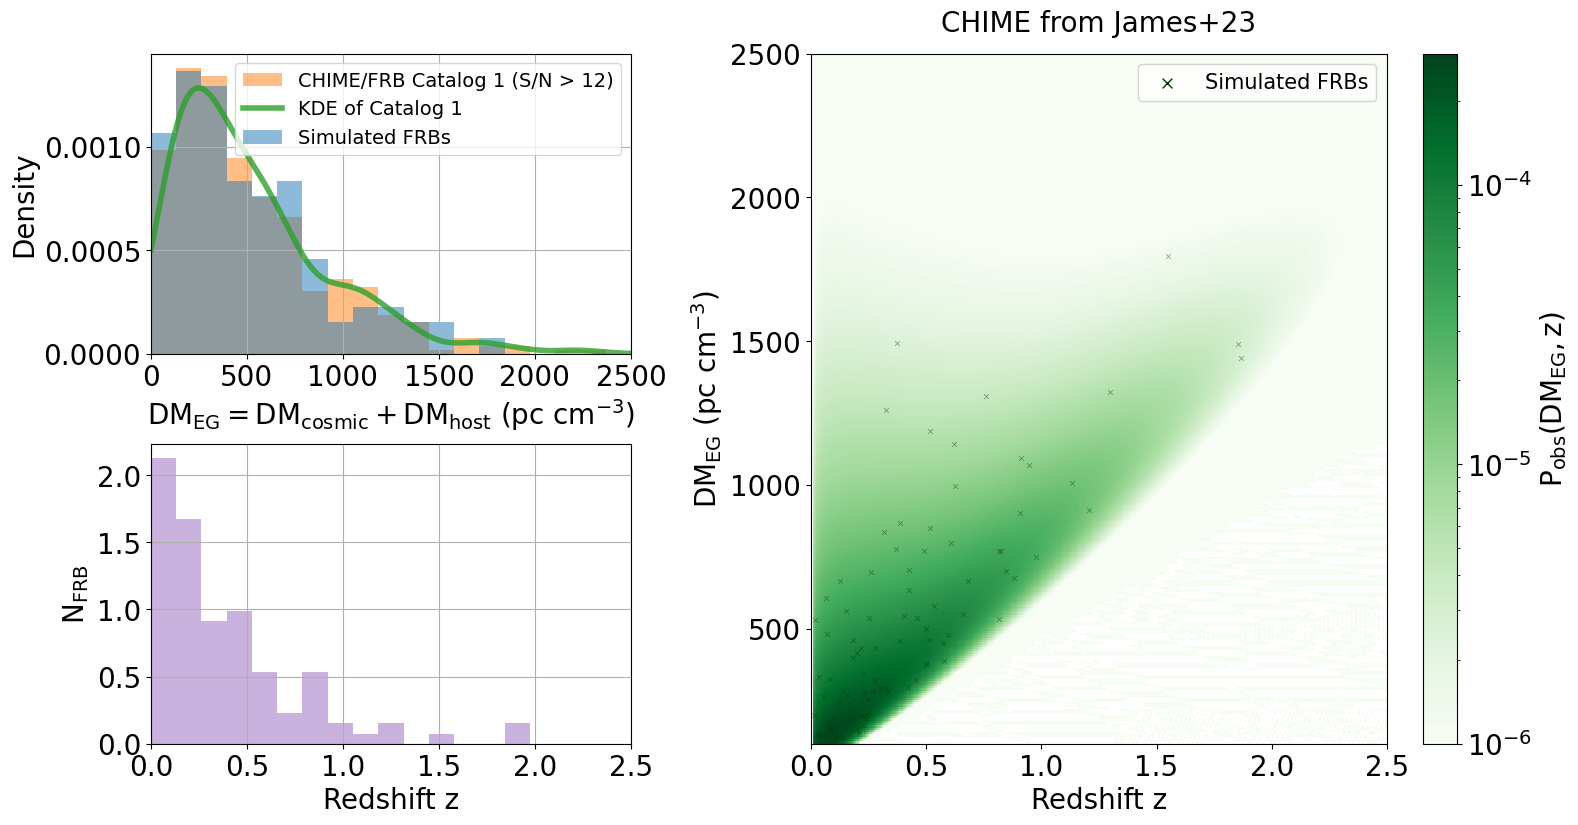

In [25]:
# Plot to verify things look as expected
fig = plt.figure(figsize=(12, 6))

# (left, bottom, width, height)
height = 1/2.
sep_h = 0.15
width = 0.4
sep_w = 0.15
ax_z = (0., 0., width, height)
ax_dmeg = (0., (height+sep_h), width, height)
ax_pzdm = (width+sep_w, 0., 0.6, height*2+sep_h)

ax = plt.axes(ax_pzdm)
my_cmap = matplotlib.colormaps['Greens'] # copy the default cmap, cubehelix
# my_cmap.set_bad((0,0,0))
pc = ax.pcolormesh(
    z_new, dm_new, Pz_dm_interp, cmap=my_cmap, 
    norm=matplotlib.colors.LogNorm(vmin=1e-6), # vmin=1e-6, vmax=2e-4
    rasterized=True,
)
plt.colorbar(pc, label=r'$\rm P_{obs}(DM_{EG},z)$')
# plt.scatter(z_samp, DM_EG_samp, color='xkcd:lightish blue', alpha=.5, s=12, linewidth=0.5, edgecolor='xkcd:dark blue', rasterized=True)
plt.scatter(zs, rand_DMex, marker='x', color='xkcd:dark green', alpha=.5, s=12, linewidth=0.5, rasterized=True, label='Simulated FRBs')
plt.xlim([0, 2.5])
plt.ylim([100, 2500])
plt.xlabel('Redshift z')
plt.ylabel(r'$\rm DM_{EG}$ (pc cm$^{-3}$)')#' = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.title(r'CHIME from James+23', fontsize=20, y=1.02) #  $\rm P_{obs}(z|DM_{EG})$
leg = plt.legend(fontsize=15)
#for lh in leg.legendHandles: 
for lh in leg.legend_handles: 
    lh.set_alpha(1)
    lh.set_sizes([50])
    lh.set_linewidth([1])
    
ax = plt.axes(ax_dmeg)
bins = np.linspace(0,2500,20)
density = True
hist = plt.hist(DMex, bins=bins, color=cycle[1], density=density, alpha=0.5, label='CHIME/FRB Catalog 1 (S/N > 12)')
plt.plot(dms, DMex_kde, color=cycle[2], alpha=0.8, lw=4, label='KDE of Catalog 1')#  / np.nanmax(DMex_kde)*np.nanmax(hist[0])
hist = plt.hist(rand_DMex, bins=bins, color=cycle[0], density=density, alpha=0.5, label='Simulated FRBs')
plt.xlim([0,2500])
plt.ylabel('Density')
plt.grid(zorder=1)
plt.legend(fontsize=14)
# _ = plt.yticks(np.arange(0, 1000+1, 500))
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')

ax = plt.axes(ax_z)
bins = np.linspace(0,2.5,20)
hist = plt.hist(zs, bins=bins, density=True, color=cycle[4], alpha=0.5)
plt.ylabel(r'$\rm N_{FRB}$')
plt.xlim([0,2.5])
plt.grid(zorder=1)
plt.xlabel(r'Redshift z')

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'frb_props_redo.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [26]:
# Build FRB table
df_frbs = pandas.DataFrame()
df_frbs['DMex'] = rand_DMex
df_frbs['z'] = zs
df_frbs['M_r'] = rand_Mr
df_frbs['m_r'] = host_m_r
output_fn = os.path.join(output_dir, 'generated_frbs_test_{}_{}.parquet'.format(int(seed), int(NFRB)))
df_frbs.to_parquet(output_fn)

# Put FRBs in Hosts
In this step, we will use a combined HECATE+DELS+HSC catalog to put these FRBs in host galaxies according to their magnitude.

In [23]:
def assign_chime_frbs_to_hosts_exponential(
    frb_tbl:pandas.DataFrame, 
    galaxy_df:pandas.DataFrame,
    outfile:str,
    localization:tuple,
    trim_catalog:units.Quantity=60*units.arcmin,
    return_df=True,
    scale:float=0.5, # half-light
):
    """
    Assigns CHIME FRBs to hosts based on given inputs.

    Writes the table to disk as a parquet file

    Args:
        frb_file (str): Path to the file containing FRB data.
        galaxy_catalog (pandas.DataFrame): DataFrame containing galaxy catalog data.
        outfile (str): Path to the output file where the results will be saved.
        localization (tuple): Tuple containing localization information (a, b, PA).

    """
    # Prep
    nsample = len(frb_tbl['m_r'])

    ra_deg = galaxy_df.ra.values * units.deg
    dec_deg = galaxy_df.dec.values * units.deg
    ra_min, ra_max = ra_deg.min(), ra_deg.max()
    dec_min, dec_max = dec_deg.min(), dec_deg.max()

    print('Trim galaxies')
    cut_ra = (ra_deg > (ra_min + trim_catalog)) & (
        ra_deg < (ra_max - trim_catalog))
    cut_dec = (dec_deg > (dec_min + trim_catalog)) & (
        dec_deg < (dec_max - trim_catalog))

    # Cut me
    cuts = cut_dec & cut_ra
    galaxy_cut = galaxy_df[cuts]

    print('Set up galaxy magnitude lists')
    fake_coords = SkyCoord(ra=np.ones(nsample),
                           dec=frb_tbl['m_r'], unit='deg')
    fake_galaxy = SkyCoord(ra=np.ones(len(galaxy_cut)),
                           dec=galaxy_cut.mag_best.values,
                           unit='deg')

    # Prep for matching
    galaxy_flag = np.ones(len(galaxy_cut), dtype=bool)
    galaxy_flag_idx = np.arange(len(galaxy_cut))
    galaxy_idx = galaxy_cut.index.values.copy()
    frb_idx = -1*np.ones(len(fake_coords), dtype=int)

    print('Match FRBs to galaxies by magnitude')
    while(np.any(frb_idx < 0)):

        print(f"Remaining: {np.sum(frb_idx < 0)}")
        print(f"Brightest: {np.min(fake_coords.dec)}")

        # Sub me
        sub_fake_coords = fake_coords[frb_idx < 0]
        sub_frb_idx = np.where(frb_idx < 0)[0]

        sub_fake_galaxy = fake_galaxy[galaxy_flag]
        sub_galaxy_idx = galaxy_idx[galaxy_flag] # Index in the full galaxy table
        sub_galaxy_flag_idx = galaxy_flag_idx[galaxy_flag] # Index for the flagging

        # Ran out of bright ones?
        if np.max(sub_fake_coords.dec.deg) < np.min(sub_fake_galaxy.dec.deg):
            srt_galaxy = np.argsort(sub_fake_galaxy.dec.deg)
            srt_frb = np.argsort(sub_fake_coords.dec.deg)
            # Set
            frb_idx[sub_frb_idx[srt_frb]] = sub_galaxy_idx[srt_galaxy[:len(srt_frb)]]
            assert np.all(frb_idx >= 0)
            mag_bright_cut = sub_fake_galaxy.dec.deg[srt_galaxy][len(sub_fake_coords)]
            print(f'Ran out of bright ones at {mag_bright_cut}')
            #embed(header='monte_carlo.py: 153')
            break


        print(f"Min: {sub_fake_coords.dec.min()}")
        print(f"Max: {sub_fake_coords.dec.max()}")

        # Match
        idx, d2d, _ = match_coordinates_sky(
            sub_fake_coords, sub_fake_galaxy,
            nthneighbor=1)

        # Worst case
        imx = np.argmax(d2d)
        #print(f'Max: {sub_fake_coords[imx]}')
        print(f'sep = {d2d[imx]}')

        # Take a cosmo galaxy only once
        uni, uni_idx = np.unique(idx, return_index=True)

        frb_idx[sub_frb_idx[uni_idx]] = sub_galaxy_idx[uni]
        galaxy_flag[sub_galaxy_flag_idx[uni]] = False

        #if debug:
        #    imn = np.argmin(fake_coords.dec)
        #    embed(header='monte_carlo.py: 116')

    print('Generating the FRB coordinates')
    galaxy_sample = galaxy_cut.loc[frb_idx]
    galaxy_coords = SkyCoord(ra=galaxy_sample.ra.values,
                             dec=galaxy_sample.dec.values,
                             unit='deg')

    # Offset the FRB in the galaxy
    # ORIGINAL:
    # theta_max = galaxy_sample.half_light.values / scale
    # randn = np.random.normal(size=10*nsample)
    # gd = np.abs(randn) < (6.*scale)
    # randn = randn[gd][0:nsample]
    # galaxy_offset = randn * theta_max * units.arcsec
    # gal_pa = np.random.uniform(size=nsample, low=0., high=360.)
    
    # UNIFORM distribution
    # randn = np.random.uniform(low=0., high=10., size=nsample)
    # galaxy_offset = randn * galaxy_sample.half_light.values * units.arcsec
    # gal_pa = np.random.uniform(size=nsample, low=0., high=360.)
    
    print('EXPONENTIAL distribution')
    randn = np.random.exponential(scale=scale, size=10*nsample)
    gd = np.abs(randn) < (6.)
    randn = randn[gd][0:nsample]
    galaxy_offset = randn * galaxy_sample.half_light.values * units.arcsec
    gal_pa = np.random.uniform(size=nsample, low=0., high=360.)

    print("Offsetting FRBs in galaxy...")
    frb_coord = [coord.directional_offset_by(
        gal_pa[kk]*units.deg, galaxy_offset[kk]) 
                 for kk, coord in enumerate(galaxy_coords)]

    true_frb_coord = frb_coord.copy()

    # Offset by Localization
    randn = np.random.normal(size=10*nsample)
    gd = np.abs(randn) < 3. # limit to 3 sigma
    randn = randn[gd]

    # TODO -- Make sure this is right
    a_off = randn[0:nsample] * localization[0] * units.arcsec
    b_off = randn[nsample:2*nsample] * localization[1] * units.arcsec
    #pa = np.arctan2(decoff, raoff) * 180./np.pi - 90.
    local_offset = np.sqrt(a_off**2 + b_off**2) 

    print("Offsetting FRB by localization...")
    frb_coord = [coord.directional_offset_by(
        localization[2]*units.deg, a_off[kk])
                 for kk, coord in enumerate(frb_coord)]
    frb_coord = [coord.directional_offset_by(
        (localization[2]+90)*units.deg, b_off[kk])
                 for kk, coord in enumerate(frb_coord)]

    # Write to disk
    df = pandas.DataFrame()
    df['ra'] = [coord.ra.deg for coord in frb_coord]
    df['dec'] = [coord.dec.deg for coord in frb_coord]
    df['true_ra'] = [coord.ra.deg for coord in true_frb_coord]
    df['true_dec'] = [coord.dec.deg for coord in true_frb_coord]
    df['gal_ID'] = galaxy_sample.ID.values
    df['gal_off'] = galaxy_offset.value # arcsec
    df['mag'] = galaxy_sample.mag_best.values
    df['half_light'] = galaxy_sample.half_light.values
    df['loc_off'] = local_offset.value # arcsec

    # Add ID
    df['FRB_ID'] = np.arange(len(frb_tbl))

    # Add localization
    df['a'] = localization[0]
    df['b'] = localization[1]
    df['PA'] = localization[2]

    df.to_parquet(outfile, index=False)
    print(f"Wrote: {outfile}")
    
    if return_df:
        return df

In [24]:
combined_file = os.path.join(os.getenv('CHIME_SANDBOX'), '../../', 'catalogs', 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet')
catalog = pandas.read_parquet(combined_file)

In [25]:
generated_frbs_fn = os.path.join(output_dir, 'generated_frbs_test_{}_{}.parquet'.format(int(seed), int(NFRB)))
frbs = pandas.read_parquet(generated_frbs_fn)

In [26]:
output_fn = os.path.join(output_dir, 'generated_hosts_DECaL_DECaLhost_hecatecut_{}_{}.parquet'.format(int(seed), int(NFRB)))
output_fn

'/arc/home/bandersen/notebooks/path_sim_code_refactor/test_results/generated_hosts_DECaL_DECaLhost_hecatecut_42_100.parquet'

In [27]:
hosts = assign_chime_frbs_to_hosts_exponential(
    frbs, catalog, output_fn, localization,
)

Trim galaxies
Set up galaxy magnitude lists
Match FRBs to galaxies by magnitude
Remaining: 100
Brightest: 11.997688480123909 deg
Min: 11.997688480123909 deg
Max: 25.212612559041634 deg
sep = 0.0036880452484222533 deg
Generating the FRB coordinates
EXPONENTIAL distribution
Offsetting FRBs in galaxy...
Offsetting FRB by localization...
Wrote: /arc/home/bandersen/notebooks/path_sim_code_refactor/test_results/generated_hosts_DECaL_DECaLhost_hecatecut_42_100.parquet


In [28]:
hosts = pandas.read_parquet(output_fn)

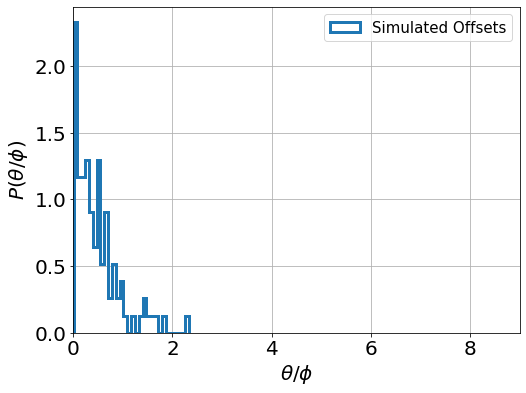

In [29]:
# Plot true FRB offsets from host center to confirm proper exponential
fig = plt.figure(figsize=(8, 6))

offsets_norm = hosts['gal_off'].values/hosts.half_light.values
vals,bins,_ = plt.hist(offsets_norm, bins=30, density=True, histtype='step', lw=3, label='Simulated Offsets')

plt.xlim([0,9])
plt.xlabel(r'$\theta/\phi$')
plt.ylabel(r'$P(\theta/\phi)$')
plt.legend(fontsize=15)
plt.grid()

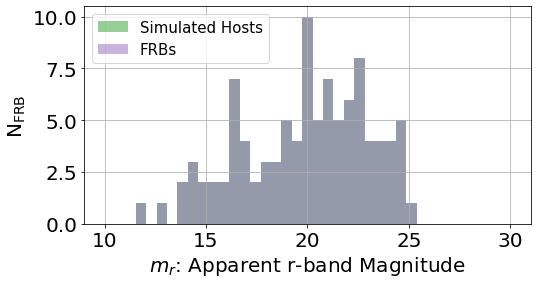

In [30]:
# Plot apparent magnitude distribution to confirm the desired distribution
# is properly reproduced
fig = plt.figure(figsize=(8,4))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

bins = np.linspace(10, 30, 40)
hist, bins, _ = plt.hist(hosts['mag'], bins=bins, color=cycle[2], lw=4, alpha=0.5, density=False, label=f"Simulated Hosts")
hist, bins, _ = plt.hist(frbs['m_r'], bins=bins, color=cycle[4], lw=4, alpha=0.5, density=False, label=f"FRBs")
plt.grid(zorder=1)
plt.ylabel(r'$\rm N_{FRB}$')
# plt.yscale('log')
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.legend(fontsize=15, loc='upper left')

# Run PATH!
Run PATH on 1000 simulated FRBs.

In [31]:
def standard_path_run(catalog_file, hosts_file, output_file='./sim_results_DECaLs.parquet', ncpu=4, return_df=True, save_df=True, multi=True):
    # Get standard DECaLs PATH priors
    prior_dict = priors.load('DECaLS_chime')
    prior_dict['PU'] = 0.15

    final_tbl = run.full(hosts_file, catalog_file, prior_dict, debug=False, ncpu=ncpu, multi=multi)
    
    if save_df:
        final_tbl.to_parquet(output_file)
    
    if return_df:
        return final_tbl

In [44]:
# Get DECaLs catalog filename to run PATH on
catalog_fn = os.path.join(output_dir, 'catalog_dudxmmlss_hecate_DECaL_{}_{}.parquet'.format(int(seed), int(NFRB)))
# Set the survey string for saving files and making plots
survey_str = 'DECaL'
# Get hosts filename
hosts_fn = os.path.join(output_dir, 'generated_hosts_DECaL_DECaLhost_hecatecut_{}_{}.parquet'.format(int(seed), int(NFRB)))
# Set filename of output simulation results
output_fn = os.path.join(output_dir, 'sim_results_DECaL_DECaLhost_hecatecut_{}_{}.parquet'.format(int(seed), int(NFRB)))


In [45]:
start = time.time()
sim_results = standard_path_run(
    catalog_fn, hosts_fn, 
    output_file=output_fn, ncpu=4,
    multi=True,
)
end = time.time()
print("Reading finished. Time elapsed: {0:.3f} seconds".format((end-start)))

Loading catalog: /arc/home/bandersen/notebooks/path_sim_code_refactor/test_results/catalog_dudxmmlss_hecate_DECaL_42_100.parquet
Slicing...
kk:  0
PATH time
Unpacking result 0
Unpacking result 1
Unpacking result 2
Unpacking result 3
Unpacking result 4
Unpacking result 5
Unpacking result 6
Unpacking result 7
Unpacking result 8
Unpacking result 9
Unpacking result 10
Unpacking result 11
Unpacking result 12
Unpacking result 13
Unpacking result 14
Unpacking result 15
Unpacking result 16
Unpacking result 17
Unpacking result 18
Unpacking result 19
Unpacking result 20
Unpacking result 21
Unpacking result 22
Unpacking result 23
Unpacking result 24
Unpacking result 25
Unpacking result 26
Unpacking result 27
Unpacking result 28
Unpacking result 29
Unpacking result 30
Unpacking result 31
Unpacking result 32
Unpacking result 33
Unpacking result 34
Unpacking result 35
Unpacking result 36
Unpacking result 37
Unpacking result 38
Unpacking result 39
Unpacking result 40
Unpacking result 41
Unpacking res

# Plot Results

In [50]:
# First make nice plotting files, that can be loaded more quickly/easily
print("Reading in data...")
generated_frbs_fn = os.path.join(output_dir, 'generated_frbs_test_{}_{}.parquet'.format(int(seed), int(NFRB)))
frbs = pandas.read_parquet(generated_frbs_fn)

hosts_fn = os.path.join(output_dir, 'generated_hosts_DECaL_DECaLhost_hecatecut_{}_{}.parquet'.format(int(seed), int(NFRB)))
hosts = pandas.read_parquet(hosts_fn).reset_index()

combined_catalog_fn = os.path.join(os.getenv('CHIME_SANDBOX'), '../../', 'catalogs', 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet')
combined_catalog = pandas.read_parquet(combined_catalog_fn)

sim_results_fn = os.path.join(output_dir, 'sim_results_DECaL_DECaLhost_hecatecut_{}_{}.parquet'.format(int(seed), int(NFRB)))
raw_sim_results = pandas.read_parquet(sim_results_fn)

print("Get parameters from the simulation results dataframe")
# (like galaxy ID, ra, dec, angular size, magnitude, separation, PATH parameters, etc)
# and append them to the hosts dataframe to construct a dataframe useful for plotting
best_cands_list = []
true_ras = []
true_decs = []
true_mags = []
true_ang_size = []
true_z = []
true_dmex = []
true_dmhost = []
true_dmcosmic = []
true_mr = []
true_Mr = []
for ii in range(len(hosts)):
    host_row = hosts[ii:ii+1]
    cands = raw_sim_results[raw_sim_results['iFRB'] == ii]
    frb = frbs.iloc[[ii]]
    # if ii == 106:
    #     print(cands)
    if len(cands) == 0:
        print(ii)
    best_cand = cands[0:1]
    best_cands_list.append(best_cand)

    orig_true_host = combined_catalog[combined_catalog['ID'] == host_row['gal_ID'].item()]
    true_ras.append(orig_true_host.ra.item())
    true_decs.append(orig_true_host.dec.item())
    true_mags.append(orig_true_host.mag_best.item())
    true_ang_size.append(orig_true_host.ang_size.item())
    true_z.append(frb['z'].values[0])
    true_dmex.append(frb['DMex'].values[0])
    true_mr.append(frb['m_r'].values[0])
    true_Mr.append(frb['M_r'].values[0])
best_cands = pandas.concat(best_cands_list, ignore_index=True)

print("Rename some columns to make concatenation cleaner")
best_cands = best_cands.rename(
    columns={
        'ra': 'ra_cand', 
        'dec': 'dec_cand',
        'mag': 'mag_cand',
        'ang_size': 'ang_size_cand',
        'sep': 'sep_cand',
        'ID': 'cand_ID',
        'gal_ID': 'gal_ind',
    },
)
hosts = hosts.rename(
    columns={
        'ra': 'ra_loc', 
        'dec': 'dec_loc',
        'mag': 'mag_host',
        'half_light': 'half_light_host',
        'gal_ID': 'host_ID',
    },
)

print("Calculate angular separation between true host and best candidate")
true_host_coord = SkyCoord(ra=true_ras, dec=true_decs, unit='deg')
best_cand_coord = SkyCoord(ra=best_cands.ra_cand.values, dec=best_cands.dec_cand.values, unit='deg')
sep = true_host_coord.separation(best_cand_coord).arcsec

print("Add the RA/Dec of the host *galaxy* from the original catalog")
hosts['ra_host'] = true_ras
hosts['dec_host'] = true_decs
hosts['mag_true_host'] = true_mags
hosts['ang_size_host'] = true_ang_size
hosts['sep_best_host'] = sep
hosts['z_host'] = true_z
hosts['dmex_host'] = true_dmex
hosts['frb_mr'] = true_mr
hosts['frb_Mr'] = true_Mr

print("Merge dataframes, to create a nice big cross-checked dataframe for plotting purposes")
df = hosts.merge(best_cands, left_index=True, right_index=True)

plotting_fn = os.path.join(output_dir, f'plot_data_{survey_str}_centroidfix_zinfo.parquet')
print("Saving to file: {}".format(plotting_fn))
df.to_parquet(plotting_fn)
print()

Reading in data...
Get parameters from the simulation results dataframe
Rename some columns to make concatenation cleaner
Calculate angular separation between true host and best candidate
Add the RA/Dec of the host *galaxy* from the original catalog
Merge dataframes, to create a nice big cross-checked dataframe for plotting purposes
Saving to file: /arc/home/bandersen/notebooks/path_sim_code_refactor/test_results/plot_data_DECaL_centroidfix_zinfo.parquet



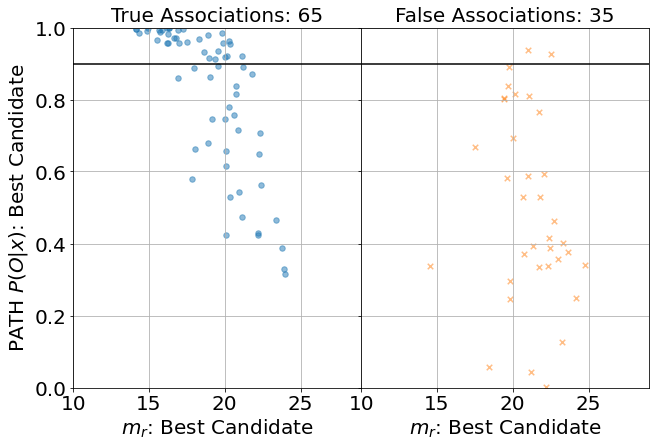

In [57]:
fig = plt.figure(figsize=(8,5))

correct_associations = df[match_criteria]
incorrect_associations = df[~match_criteria]

# (left, bottom, width, height)
correct = (0, 0., 0.5, 1.)
incorrect = (0.5, 0., 0.5, 1.)

# Number of contour levels
n_levels = 30

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = plt.axes(correct)
plt.scatter(correct_associations['mag_cand'], correct_associations['P_Ox'], color=cycle[0], marker='o', s=30, alpha=0.5, label='Correct Association')
plt.xlabel(r'$m_r$: Best Candidate')
plt.ylabel(r'PATH $P(O|x)$: Best Candidate')
plt.title('True Associations: {}'.format(len(correct_associations)))
plt.grid(zorder=20)
plt.ylim([0,1])
plt.xlim([10,29])
#     plt.axvline(x=18, color='black')
plt.axhline(y=0.9, color='black')

ax = plt.axes(incorrect)
plt.scatter(incorrect_associations['mag_cand'], incorrect_associations['P_Ox'], color=cycle[1], marker='x', s=30, alpha=0.5, label='Incorrect Association')
plt.xlabel(r'$m_r$: Best Candidate')
ax.set_yticklabels([])
plt.title('False Associations: {}'.format(len(incorrect_associations)))
plt.grid(zorder=20)
plt.ylim([0,1])
plt.xlim([10,29])
#     plt.axvline(x=18, color='black')
plt.axhline(y=0.9, color='black')

# Make a Smaller Catalog for the Test
The catalog file is prohibitively huge. Requires a lot of RAM. Let's make a smaller file just for this test.

In [35]:
# Create smaller catalog for selected hosts
hosts_fn = output_fn = os.path.join(output_dir, 'generated_hosts_DECaL_DECaLhost_hecatecut_{}_{}.parquet'.format(int(seed), int(NFRB)))
hosts = pandas.read_parquet(hosts_fn)

In [36]:
catalog_fn = os.path.join(os.getenv('CHIME_SANDBOX'), '../../', 'catalogs', 'catalog_dudxmmlss_hecate_DECaL.parquet')
catalog = pandas.read_parquet(catalog_fn)

In [37]:
catalog

,DECaL_r,DECaL_ID,ra,dec,gaia_pointsource,shapedev_r,shapeexp_r,type,mag,ang_size,ID
0,19.359713,8796111557952818,322.094807,-8.565754,0,0.0,1.533299,EXP,19.359713,1.533299,8796111557952818
1,23.396738,8796111557952932,322.091840,-8.565780,0,0.0,0.451134,REX,23.396738,0.451134,8796111557952932
2,21.111647,8796111557952936,322.074123,-8.565365,0,0.0,0.440460,REX,21.111647,0.440460,8796111557952936
3,22.958508,8796111557952939,322.073056,-8.560549,0,0.0,0.434113,REX,22.958508,0.434113,8796111557952939
4,23.374249,8796111557952945,322.069338,-8.565061,0,0.0,1.354752,EXP,23.374249,1.354752,8796111557952945
...,...,...,...,...,...,...,...,...,...,...,...
105593080,23.566250,8797232204875362,226.379470,55.970854,0,0.0,0.345398,REX,23.566250,0.345398,8797232204875362
105593081,22.928835,8797232204875376,226.372608,55.971111,0,0.0,0.182609,REX,22.928835,0.182609,8797232204875376
105593082,23.795180,8797232204875388,226.439113,55.972176,0,0.0,0.232823,REX,23.795180,0.232823,8797232204875388
105593083,22.515533,8797232204875392,226.377601,55.972486,0,0.0,0.601221,REX,22.515533,0.601221,8797232204875392


In [39]:
host_coords = SkyCoord(ra=hosts.ra.values, dec=hosts.dec.values, unit='deg', frame='icrs')
catalog_coords = SkyCoord(ra=catalog.ra.values, dec=catalog.dec.values, unit='deg', frame='icrs')

In [40]:
# Cross-match and select only parts of catalog surrounding selected hosts
# Set the separation limit to 1 arcmin to fit 3-sigma KKO localization
sep_limit = 2. * u.arcmin
# Perform the search
# idx1, idx2 are the indices of the matched pairs in coords1 and coords2, respectively
# d2d is the on-sky separation of the pairs
idx1, idx2, sep2d, _ = catalog_coords.search_around_sky(host_coords, sep_limit)


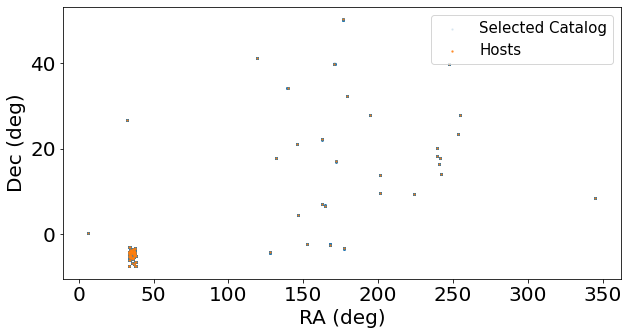

In [41]:
fig = plt.figure(figsize=(10,5))
plot_cat = catalog.iloc[idx2]
plt.scatter(plot_cat['ra'], plot_cat['dec'], s=2, alpha=0.1, label='Selected Catalog')
plot_cat = hosts
plt.scatter(plot_cat['ra'], plot_cat['dec'], s=2, alpha=0.7, label='Hosts')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.legend(loc='upper right', fontsize=15)

In [42]:
output_fn = os.path.join(output_dir, 'catalog_dudxmmlss_hecate_DECaL_{}_{}.parquet'.format(int(seed), int(NFRB)))
catalog.iloc[idx2].to_parquet(output_fn)

In [43]:
catalog.iloc[idx2]

,DECaL_r,DECaL_ID,ra,dec,gaia_pointsource,shapedev_r,shapeexp_r,type,mag,ang_size,ID
103192675,21.997700,8796112233304335,37.959534,-6.485705,0,1.082053,0.000000,DEV,21.997700,1.082053,8796112233304335
103192811,21.345285,8796112233304576,37.960742,-6.479862,0,0.000000,0.976710,EXP,21.345285,0.976710,8796112233304576
103192812,24.117641,8796112233304578,37.960531,-6.482304,0,0.000000,0.479416,REX,24.117641,0.479416,8796112233304578
103192870,20.996317,8796112233304703,37.958165,-6.477590,0,0.000000,0.338419,REX,20.996317,0.338419,8796112233304703
103193106,22.488293,8796112233305114,37.960828,-6.465710,0,0.000000,0.426088,REX,22.488293,0.426088,8796112233305114
...,...,...,...,...,...,...,...,...,...,...,...
7307762,24.692347,8796116409518424,146.542102,4.497261,0,0.000000,0.462348,REX,24.692347,0.462348,8796116409518424
7307779,23.432920,8796116409518449,146.554561,4.499136,0,0.000000,0.230801,REX,23.432920,0.230801,8796116409518449
7307805,23.579970,8796116409518490,146.550162,4.501175,0,0.000000,0.506007,REX,23.579970,0.506007,8796116409518490
7307808,22.676386,8796116409518494,146.542616,4.500635,0,0.000000,0.537407,EXP,22.676386,0.537407,8796116409518494
